


# Vamos encher o carrinho!

# Introdução

O Instacart é uma plataforma de entrega de supermercado onde os clientes podem fazer um pedido no supermercado e depois receber sua compra, semelhante ao funcionamento do Uber Eats e do iFood. O conjunto de dados que fornecemos foi modificado a partir do original. Reduzimos o tamanho dele para que seus cálculos sejam executados mais rapidamente e incluímos valores ausentes e duplicados. Também tivemos o cuidado de preservar as distribuições dos dados originais quando fizemos as alterações.

Você precisa completar três etapas. Para cada uma delas, escreva uma breve introdução descrevendo como você pretende concluir a etapa e justifique suas decisões em parágrafos explicativos a medida que você avança na solução. Escreva também uma conclusão para resumir suas conclusões e escolhas.



## Dicionário de dados

Há cinco tabelas no conjunto de dados, e você vai precisar usar todas elas para pré-processar seus dados e fazer AED. Abaixo está um dicionário que lista as colunas de cada tabela e descreve os dados contidos nelas.

- `instacart_orders.csv`: cada linha corresponde a um pedido no aplicativo da Instacart
    - `'order_id'`: é o número que identifica cada pedido de forma exclusiva
    - `'user_id'`: é o número de identificação exclusivo da conta de cada cliente
    - `'order_number'`: é o número de vezes que o cliente fez um pedido
    - `'order_dow'`: é o dia da semana em que o pedido foi feito (0 é domingo)
    - `'order_hour_of_day'`: é a hora do dia em que o pedido foi feito
    - `'days_since_prior_order'`: é o número de dias desde que o cliente fez seu pedido anterior




- `products.csv`: cada linha corresponde a um produto exclusivo que os clientes podem comprar
    - `'product_id'`: é o número de identificação unívoco de cada produto
    - `'product_name'`: é o nome do produto
    - `'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - `'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado




-	`order_products.csv`: cada linha corresponde a um item incluído em um pedido
    -	`'order_id'`: é o número que identifica cada pedido de forma exclusiva
    -	`'product_id'`: é o número de identificação exclusivo de cada produto
    -	`'add_to_cart_order'`: é a ordem sequencial em que cada item foi colocado no carrinho
    -	`'reordered'`: 0 se o cliente nunca comprou o produto antes, 1 se já o comprou




-	`aisles.csv`
    -	`'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    -	`'aisle'`: é o nome do corredor



-	`departments.csv`
    -	`'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado
    -	`'department'`: é o nome do departamento


# Etapa 1. Visão geral dos dados

Leia os arquivos de dados (/datasets/instacart_orders.csv, /datasets/products.csv, /datasets/aisles.csv, /datasets/departments.csv e /datasets/order_products.csv) com `pd.read_csv()` usando os parâmetros apropriados para fazer isso corretamente. Verifique as informações para cada DataFrame criado.


## Plano de solução

Escreva aqui seu plano para a Etapa 2. Visão geral dos dados

Vou abrir os arquivos diretamente no Excel e Bloco de notas para verificar os separadores. Depois vou importar as bibliotecas e ler os arquivos.

In [1]:
# Importe as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# leia os conjuntos de dados em DataFrames
orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products = pd.read_csv('/datasets/products.csv', sep=';')
aisles = pd.read_csv('/datasets/aisles.csv', sep=';')
departments = pd.read_csv('/datasets/departments.csv', sep=';')
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')

In [3]:
# imprima as informações sobre o DataFrame
print(orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
None


In [4]:
# imprima as informações sobre o DataFrame
print(products.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


In [5]:
# imprima as informações sobre o DataFrame
print(aisles.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
None


In [6]:
# imprima as informações sobre o DataFrame
print(departments.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes
None


In [7]:
# imprima as informações sobre o DataFrame
print(order_products.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None


## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 1. Visão geral dos dados

### Conclusões por DF

#### Orders

A coluna days_since_prior_order possui alguns valores com valores Nulos. Os tipos das colunas parecem certos baseado na documentação, sendo todos int64, com exceção da coluna days_since_prior_order, que me deixa um pouco em dúvida, afinal, valores float em dias podem fazer sentido mas dificultar a visualização.

#### Products

A coluna product_name possui alguns valores nulos. Todos os tipos parecem corretos.

#### Aisles

A tabela Aisles não parece ter nenhum dado nulo e os tipos correspondem com a descrição da tabela.

#### Departments

Semelhante a tabela Aisles, não parece ter nenhum dado nulo, e os tipos de dados das colunas correspondem com a documentação.

#### Order_products

Essa tabela é a que mais possui dados, sendo a mais robusta. Não está mostrando os valores nulos.

# Etapa 2. Preparação de dados

Faça o pré-processamento dos dados da seguinte maneira:

-	Verifique e corrija os tipos de dados (por exemplo, certifique-se de que as colunas de ID sejam números inteiros)
-	Identifique e preencha valores ausentes
-	Identifique e remova valores duplicados

Certifique-se de explicar que tipos de valores ausentes e duplicados você encontrou, como você os preencheu ou removeu, por que escolheu esses métodos e por que você acha que esses valores ausentes e duplicados estavam presentes no conjunto de dados.

## Plano de solução

Escreva aqui seu plano para a Etapa 2. Preparação de dados

Validar cada um dos DFs individualmente, passando pelas colunas e rodando Samples, para ter amostras de dados diferentes. Após validar, verificar duplicados, ausentes, etc.

## Encontre e remova valores duplicados (e descreva por que você está fazendo suas escolhas)

### DataFrame `instacart_orders`

In [8]:
# Verificar se há pedidos duplicados
duplicados_orders = orders[orders['order_id'].duplicated()]
print(duplicados_orders)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48          3 

Há linhas duplicadas? Se sim, o que elas têm em comum?

Sim, há. Aparentemente os pedidos duplicados ocorreram no mesmo dia da semana e no mesmo horário, o que pode indicar um problema no sistema de dados ou uma duplicação no sistema de pedidos.

In [9]:
# Com base nas suas conclusões,

# verifique todos os pedidos feitos às 2h da manhã nas quartas-feiras

pedidos_quarta = orders[
    (orders['order_dow'] == 3) &
    (orders['order_hour_of_day'] == 2)
]

print(pedidos_quarta)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

O que esse resultado quer dizer?

Aparentemente, todos os duplicados foram feitos nesse dia e nesse horário.

In [10]:
# Remova pedidos duplicados
duplicados_orders = orders.drop_duplicates(inplace = True)
print(duplicados_orders)

None


In [11]:
# Verifique as linhas duplicadas mais uma vez
print(duplicados_orders)

None


In [12]:
# Verifique novamente apenas os IDs de pedidos duplicados
print(orders['order_id'])

0         1515936
1         1690866
2         1454967
3         1768857
4         3007858
           ...   
478962    3210681
478963    3270802
478964     885349
478965     216274
478966    2071924
Name: order_id, Length: 478952, dtype: int64


Descreva brevemente suas conclusões e o que você fez com elas.

Acredito que houve algum erro de sistema na quarta-feira às 2h, pois houveram vários problemas de duplicados nesse horário. Após descobrir, fiz uma limpa no DF, diminuindo as entradas de 478967 para 478952. Mas ainda existem alguns valores NaNs

### DataFrame `products`

In [13]:
# Verifique se há linhas completamente duplicadas
duplicados_products = products[products.duplicated()]
print(duplicados_products)

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


In [14]:
# Verifique apenas IDs dos produtos duplicados
duplicados_products_ids = products[products['product_id'].duplicated()]
print(duplicados_products_ids)

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


In [15]:
# Verifique apenas nomes de produtos duplicados (converta os nomes para minúsculas para uma comparação melhor
duplicados_products_names = products[products['product_name'].str.lower().duplicated()]
print(duplicados_products_names)

       product_id                                     product_name  aisle_id  \
71             72                                              NaN       100   
109           110                                              NaN       100   
296           297                                              NaN       100   
416           417                                              NaN       100   
436           437                                              NaN       100   
...           ...                                              ...       ...   
49689       49690                    HIGH PERFORMANCE ENERGY DRINK        64   
49690       49691                    ORIGINAL PANCAKE & WAFFLE MIX       130   
49691       49692  ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR       130   
49692       49693                           SPRING WATER BODY WASH       127   
49693       49694                          BURRITO- STEAK & CHEESE        38   

       department_id  
71              

In [16]:
# Verifique os nomes de produtos duplicados que não estão faltando
duplicados_products_names_nnull = produtos_validos = products[products['product_name'].notna().duplicated()]
print(duplicados_products_names_nnull)

       product_id                                       product_name  \
1               2                                   All-Seasons Salt   
2               3               Robust Golden Unsweetened Oolong Tea   
3               4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
4               5                          Green Chile Anytime Sauce   
5               6                                       Dry Nose Oil   
...           ...                                                ...   
49689       49690                      HIGH PERFORMANCE ENERGY DRINK   
49690       49691                      ORIGINAL PANCAKE & WAFFLE MIX   
49691       49692    ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR   
49692       49693                             SPRING WATER BODY WASH   
49693       49694                            BURRITO- STEAK & CHEESE   

       aisle_id  department_id  
1           104             13  
2            94              7  
3            38              1  
4  

Descreva brevemente suas conclusões e o que você fez com elas.

Encontrei vários valores ausentes na coluna product_name, mas não acho que haja nenhum valor duplicado.

### DataFrame `departments`

In [17]:
# Verifique se há linhas completamente duplicadas
departments_duplicados = departments[departments.duplicated()]
print(departments_duplicados)

Empty DataFrame
Columns: [department_id, department]
Index: []


In [18]:
# Verifique apenas se há IDs dos produtos duplicados
departments_duplicados_id = departments[departments['department_id'].duplicated()]
print(departments_duplicados_id)

Empty DataFrame
Columns: [department_id, department]
Index: []


Descreva brevemente suas conclusões e o que você fez com elas.
Feito a verificação de duplicados no DF, não foi encontrado nada.

### DataFrame `aisles`

In [19]:
# Verifique se há linhas completamente duplicadas
aisles_duplicados = aisles[aisles.duplicated()]
print(aisles_duplicados)

Empty DataFrame
Columns: [aisle_id, aisle]
Index: []


In [20]:
# Verifique apenas se há IDs dos produtos duplicados
aisles_duplicados_ids = aisles[aisles['aisle_id'].duplicated()]
print(aisles_duplicados_ids)

Empty DataFrame
Columns: [aisle_id, aisle]
Index: []


Descreva brevemente suas conclusões e o que você fez com elas.
Não há valores duplicados no DF Aisles.

### DataFrame `order_products`

In [21]:
# Verifique se há linhas completamente duplicadas
order_products_duplicados = order_products[order_products.duplicated()]
print(order_products_duplicados)

Empty DataFrame
Columns: [order_id, product_id, add_to_cart_order, reordered]
Index: []


In [22]:
# Verifique mais uma vez se há outros casos complicados de duplicados
order_products_duplicados_order_id = order_products[order_products['order_id'].duplicated()]
print(order_products_duplicados)


Empty DataFrame
Columns: [order_id, product_id, add_to_cart_order, reordered]
Index: []


Descreva brevemente suas conclusões e o que você fez com elas.
Não há valores duplicados

## Encontre e remova valores ausentes


Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

*	A coluna `'product_name'` da tabela products.
*	A coluna `'days_since_prior_order'` da tabela orders.
*	A coluna `'add_to_cart_order'` da tabela order_products.


### DataFrame `products`

In [23]:
# Encontre valores ausentes na coluna 'product_name'
products_ausentes = products[products['product_name'].isna()]
print(products_ausentes)

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Descreva brevemente suas conclusões.
Encontramos 1258 valores ausentes na coluna 'product_name'.

In [24]:
# Todos os nomes de produtos ausentes estão associados com o corredor de ID 100?
products_ausentes_aisles = products[products['product_name'].isna()]
aisles_unique = products_ausentes_aisles['aisle_id'].unique()
print(aisles_unique)

[100]


Descreva brevemente suas conclusões.

Sim, todos os valores estão associados com o corredor ID 100

In [25]:
# Todos os nomes de produtos ausentes estão associados com o departamento de ID 21?
products_ausentes_department = products[products['product_name'].isna()]
department_unique = products_ausentes_department['department_id'].unique()
print(department_unique)

[21]


Descreva brevemente suas conclusões.

Sim também, todos eles estão associados com o departamento de ID 21

In [26]:
# Use as tabelas department e aisle para verificar os dados do corredor com ID 100 e do departamento com ID 21.
aisle_100 = products[products['aisle_id'] == 100]
print(aisle_100)

department_21 = products[products['department_id'] == 21]
print(department_21)

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]
       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417      

Descreva brevemente suas conclusões.
Tanto o corredor quando o departamento estão associados apenas com os produtos com nomes com valores nulos.

In [27]:
# Preencha nomes de produtos ausentes com 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknow')
print(products['product_name'].isna().sum)

<bound method NDFrame._add_numeric_operations.<locals>.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
49689    False
49690    False
49691    False
49692    False
49693    False
Name: product_name, Length: 49694, dtype: bool>


Descreva brevemente suas conclusões e o que você fez com elas.

Todos os produtos com nomes ausentes estavam associados ao corredor ID 100 e também ao departamento 21, o que pode indicar uma falha de cadastro nesse setor. Foi alterado os valores nulos para "Unknow", para auxilio em análises futuras, prevenindo erros por valores nulos.

### DataFrame `orders`

In [28]:
# Encontre os valores ausentes
orders_ausentes = orders.isna().sum()
print(orders_ausentes)

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64


In [29]:

# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?
orders_ausentes_primeiro = orders[
    (orders['days_since_prior_order'].isna()) &
    (orders['order_number'] > 1)
]

print(orders_ausentes_primeiro.head())


Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


Descreva brevemente suas conclusões e o que você fez com elas.

Verifiquei se a coluna "days_since_prior_order" retornava nulo apenas no caso de nenhuma compra ter sido feita. Como retornou um Empty DataFrame, é seguro dizer que o sistema está funcionando corretamente.

### DataFrame `order_products`

In [30]:
# Encontre os valores ausentes
order_products_null = order_products.isna().sum()
print(order_products_null)

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


In [31]:
# Quais são os valores mínimo e máximo dessa coluna?
print(order_products['add_to_cart_order'].min())
print(order_products['add_to_cart_order'].max())


1.0
64.0


Descreva brevemente suas conclusões.

Após passar os métodos min e max, é possível verificar que os valores são, respectivamente, 1.0 e 64.0

In [32]:
# Salve todos os IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order'
orders_com_ausentes = order_products[order_products['add_to_cart_order'].isna()]
ids_pedidos_ausentes = orders_com_ausentes['order_id'].unique()

print(ids_pedidos_ausentes)

[2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093  129627  293169 2849370 1386261 3308010  903110 2136777 3347453
 1888628  165801 2094761 1038146 2997021  813364 2256933  171934 2409109
 1730767 1169835  733526  404157 3125735  747668 1800005 1961723  871281
  388234 1648217 1477139  102236 1021563 1832957 2721963  678116 1220886
 1673227 2999801 1633337 2470674 2625444 1677118 2479011 3383594 1183255
 1713430 2652650 1598369 1916118  854647 1302315  888470  180546 2621907
 1308785 2729254    9310 2170451 2979697 1625713 1529171]


In [33]:
# Todos os pedidos com valores ausentes contêm mais de 64 produtos?
# Agrupe os pedidos com dados ausentes por ID de pedido
# Conte o número de 'product_id' em cada pedido e verifique o valor mínimo da contagem
miss_cart_order_ids = sorted(
    list(
        order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()
    )
)

pedidos_com_ausencia = order_products[order_products['order_id'].isin(miss_cart_order_ids)]

contagem_por_pedido = pedidos_com_ausencia.groupby('order_id').size().sort_values()

print(contagem_por_pedido)

order_id
9310        65
747668      65
1598369     65
1677118     65
2170451     65
          ... 
1959075     98
171934     104
2136777    108
3308010    115
61355      127
Length: 70, dtype: int64


In [34]:

# miss_cart_order_ids = sorted(list(order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()))
# order_products[order_products['order_id'].isin(miss_cart_order_ids)].groupby('order_id').size().sort_values()

Descreva brevemente suas conclusões.

Todos os pedidos com valores ausentes parecem ter mais de 64 produtos, pois o menor valor encontrado entre eles é 65.

In [35]:
# Substitua valores ausentes na coluna 'add_to_cart_order' por 999 e converta a coluna para o tipo integer
order_products["add_to_cart_order"] = order_products["add_to_cart_order"].fillna(999)
order_products["add_to_cart_order"] = order_products["add_to_cart_order"].astype(int)

print(order_products["add_to_cart_order"].dtype)

int64


Descreva brevemente suas conclusões e o que você fez com elas.

Passado o método fillna para substituir os valores por 999, e então usado o astype para alterar a coluna para o tipo int.

## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 2. Preparação de dados

Foi feita uma série de verificações e ajustes para garantir que os DFs estivessem limpos e consistentes. Primeiro foi corrigido os tipos de dados, e em seguida verificamos os valores duplicados. Em seguida, verificamos valores ausentes, e foi possível verificar 3 casos principais, sendo eles:

products.product_name, que possuia 1258 valores ausentes, todos associados ao corredor de ID 100 e também ao departamento de ID21.
orders.day_since_prior_order, que possuia 28817 valores ausentes, todos correspondentes ao primeiro pedido do cliente, o que é esperado e não houve necessidade de intervenção.
order_products.add_to_cart_order, possuia 836 valores ausentes, que foram substituídos por 999 e então convertidos para inteiro.

# Etapa 3. Análise de dados

Quando os dados estiverem processados ​​e prontos, execute a seguinte análise:

# [A] Fácil (é necessário concluir tudo para passar)

1.	Verifique se os valores nas colunas `'order_hour_of_day'` e `'order_dow'` na tabela `orders` fazem sentido (ou seja, os valores da coluna  `'order_hour_of_day'` variam de 0 a 23 e os da `'order_dow'` variam de 0 a 6).
2.	Crie um gráfico que mostre quantas pessoas fazem pedidos a cada hora do dia.
3.	Crie um gráfico que mostre em que dia da semana as pessoas fazem compras.
4.	Crie um gráfico que mostre quanto tempo as pessoas esperam até fazer seu próximo pedido e comente sobre os valores mínimo e máximo.


### [A1] Verifique se os valores fazem sentido

In [36]:
print(orders['order_hour_of_day'].min())
print(orders['order_hour_of_day'].max())

0
23


In [37]:
print(orders['order_dow'].min())
print(orders['order_dow'].max())

0
6


Escreva suas conclusões aqui

As colunas order_hour_of_day e order_dow possuem os valores dentro dos limites esperados.

### [A2] Quantas pessoas fazem pedidos a cada hora do dia?

0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_hour_of_day, dtype: int64


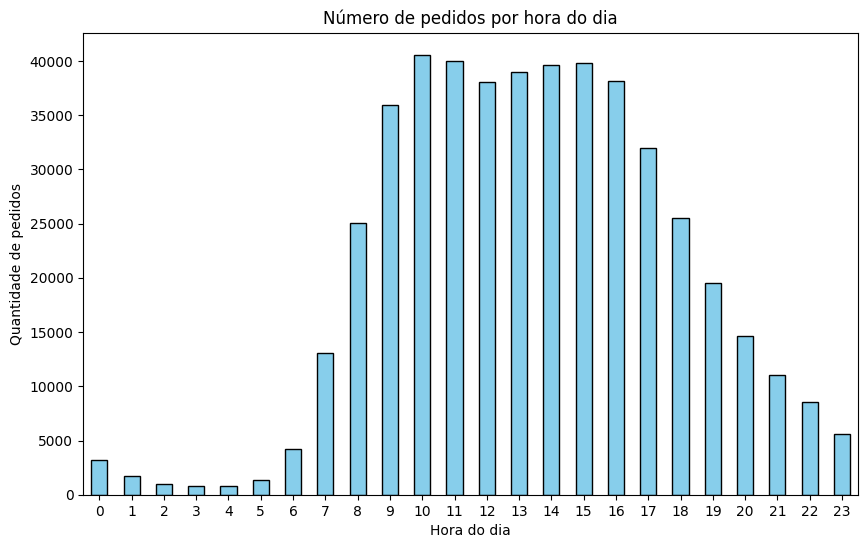

In [38]:
pedidos_por_hora = orders['order_hour_of_day'].value_counts().sort_index()
print(pedidos_por_hora)

plt.figure(figsize=(10,6))
pedidos_por_hora.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Número de pedidos por hora do dia")
plt.xlabel("Hora do dia")
plt.ylabel("Quantidade de pedidos")
plt.xticks(rotation=0)
plt.show()

Escreva suas conclusões aqui

As pessoas alcançaram o pico de compras por volta das 10h até às 16h, chegando a um valor máximo próximo de 40 mil. E o menor valor observado está entre as 2h e 4h, onde não alcançam a marca de 5 mil. É um padrão típico de comportamento diário de consumidores, muitas compras durante o dia, com queda gradual à noite e na madrugada.

### [A3] Em que dia da semana as pessoas compram produtos alimentícios?

0    84090
1    82185
2    65833
3    60897
4    59810
5    63488
6    62649
Name: order_dow, dtype: int64


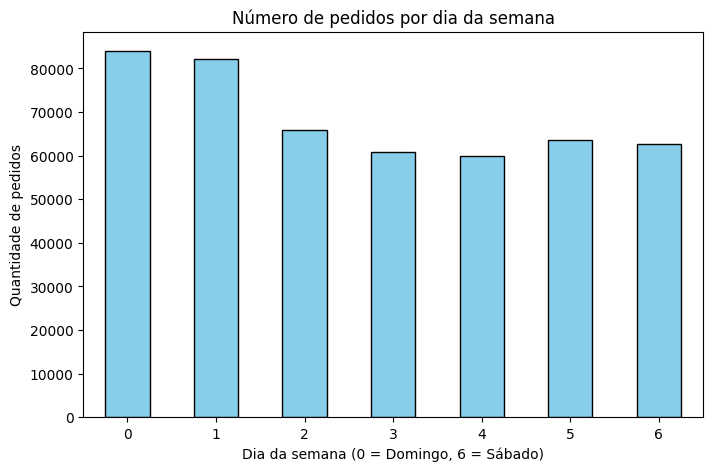

In [39]:
pedidos_por_dia = orders['order_dow'].value_counts().sort_index()
print(pedidos_por_dia)

plt.figure(figsize=(8,5))
pedidos_por_dia.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Número de pedidos por dia da semana")
plt.xlabel("Dia da semana (0 = Domingo, 6 = Sábado)")
plt.ylabel("Quantidade de pedidos")
plt.xticks(rotation=0)
plt.show()

Escreva suas conclusões aqui

É possível observar que os clientes fazem seus pedidos principalmente no domingo e segunda-feira, com um mínimo expressivo no sábado.

### [A4] Quanto tempo as pessoas esperam até fazer outro pedido?

Escreva suas conclusões aqui

O comportamento da maioria dos clientes parece ser semanal, com menor frequencia para compras espaçadas ou mensais. O pico em 30 dias também sugere que há um limite artificial ou um hábito de compras mensais registrado no sistema, por ser um supermercado de delivery.

0         30.0
1          9.0
2          2.0
3         10.0
4         17.0
          ... 
478962     7.0
478963     6.0
478964     6.0
478965     8.0
478966    15.0
Name: days_since_prior_order, Length: 450135, dtype: float64


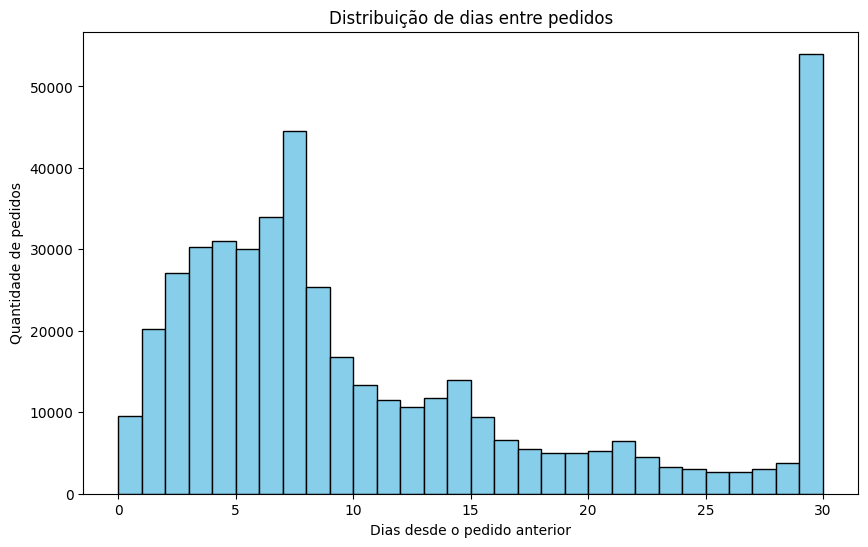

0.0
30.0


In [40]:
dias_entre_pedidos = orders['days_since_prior_order'].dropna()
print(dias_entre_pedidos)

plt.figure(figsize=(10,6))
plt.hist(dias_entre_pedidos, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribuição de dias entre pedidos")
plt.xlabel("Dias desde o pedido anterior")
plt.ylabel("Quantidade de pedidos")
plt.show()

print(dias_entre_pedidos.min())
print(dias_entre_pedidos.max())

# [B] Médio (é necessário concluir tudo para passar)

1.	Há alguma diferença nas distribuições de `'order_hour_of_day'` nas quartas e sábados? Construa gráficos de barras para ambos os dias no mesmo gráfico e descreva as diferenças que você notou.
2.	Construa um gráfico de distribuição para o número de pedidos que os clientes fazem (ou seja, quantos clientes fizeram apenas 1 pedido, quantos fizeram apenas 2, quantos apenas 3, etc.)
3.	Quais são os 20 produtos comprados com mais frequência? Exiba os IDs e nomes.


### [B1] Diferenças nas quartas e sábados em `'order_hour_of_day'`. Crie gráficos de barras para ambos os dias e descreva as diferenças.

In [41]:
pedidos_quarta = orders[orders['order_dow'] == 3]
pedidos_sabado = orders[orders['order_dow'] == 6]

In [42]:
contagem_quarta = pedidos_quarta['order_hour_of_day'].value_counts().sort_index()
contagem_sabado = pedidos_sabado['order_hour_of_day'].value_counts().sort_index()

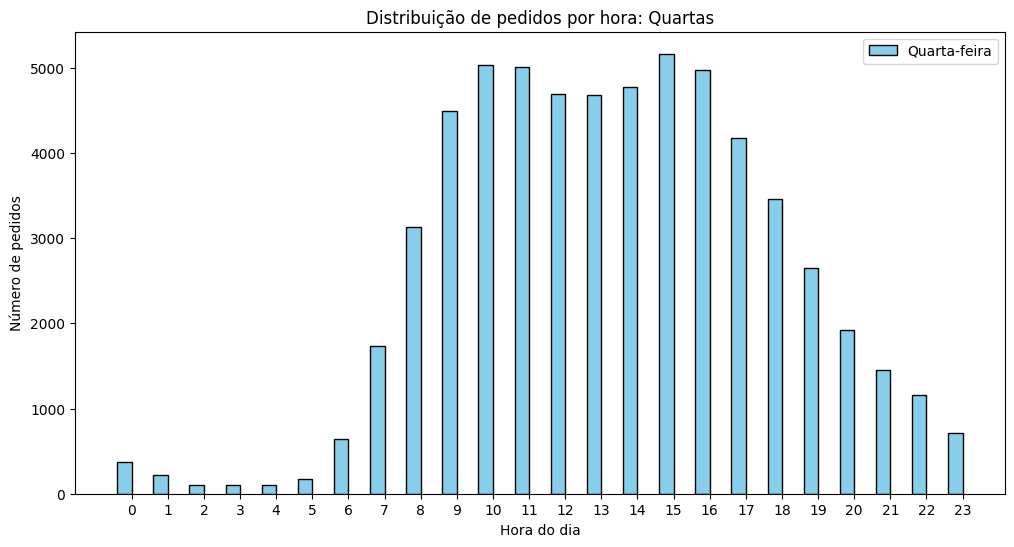

In [43]:
plt.figure(figsize=(12,6))
plt.bar(contagem_quarta.index - 0.2, contagem_quarta.values, width=0.4, label='Quarta-feira', color='skyblue', edgecolor='black')
plt.xlabel('Hora do dia')
plt.ylabel('Número de pedidos')
plt.title('Distribuição de pedidos por hora: Quartas')
plt.xticks(range(0,24))
plt.legend()
plt.show()

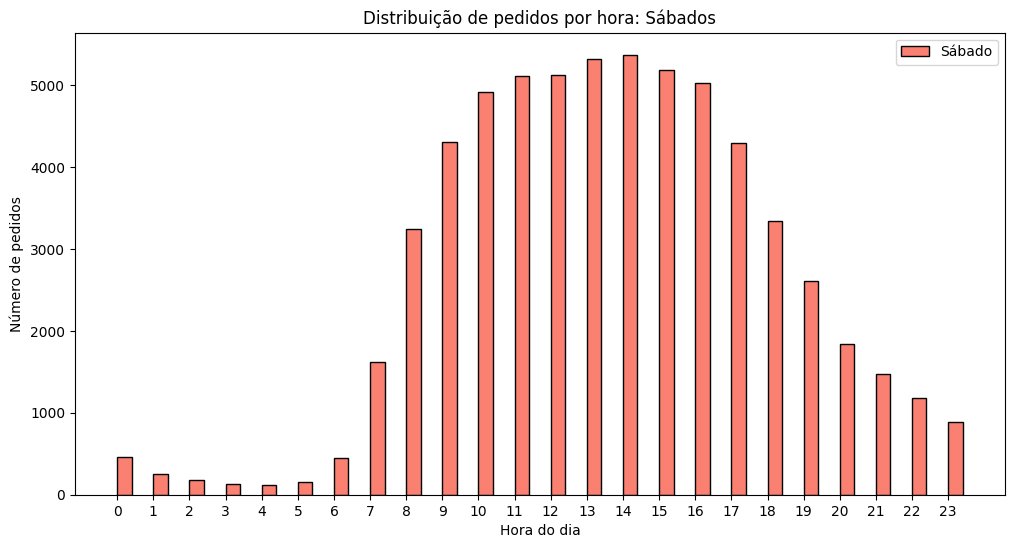

In [44]:
plt.figure(figsize=(12,6))
plt.bar(contagem_sabado.index + 0.2, contagem_sabado.values, width=0.4, label='Sábado', color='salmon', edgecolor='black')
plt.xlabel('Hora do dia')
plt.ylabel('Número de pedidos')
plt.title('Distribuição de pedidos por hora: Sábados')
plt.xticks(range(0,24))
plt.legend()
plt.show()

Escreva suas conclusões aqui

É possível ver um pico em ambos os gráficos na parte da tarde, entre 10h e 16h, mas é notável que no sábado, o pico se mantem, alcançando o seu maior valor as 14h, ao contrário das quartas, onde é possível verificar esse comportamento às 15h.

### [B2] Qual é a distribuição do número de pedidos por cliente?

In [45]:
pedidos_por_cliente = orders.groupby('user_id')['order_number'].max()
distribuicao_pedidos = pedidos_por_cliente.value_counts().sort_index()

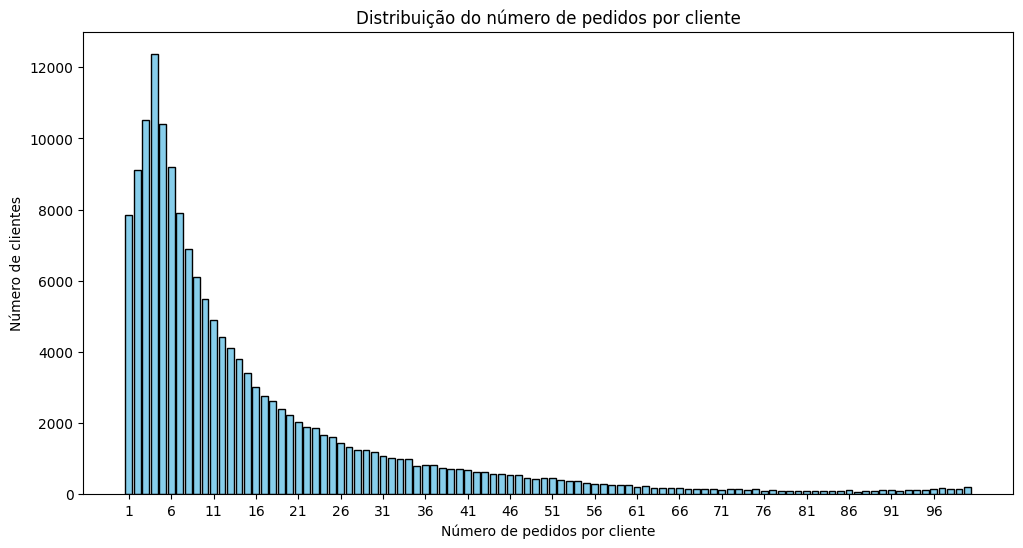

In [46]:
plt.figure(figsize=(12,6))
plt.bar(distribuicao_pedidos.index, distribuicao_pedidos.values, color='skyblue', edgecolor='black')
plt.xlabel('Número de pedidos por cliente')
plt.ylabel('Número de clientes')
plt.title('Distribuição do número de pedidos por cliente')
plt.xticks(range(1, distribuicao_pedidos.index.max()+1, 5))
plt.show()

Escreva suas conclusões aqui

A análise do gráfico mostra um padrão de compra onde a maioria dos clientes realiza poucos pedidos, com um pico em cerca de 3~6 pedidos, enquanto um número muito menor de clientes faz muito pedidos, chegando a mais de 100.

### [B3] Quais são os 20 produtos mais populares? Exiba os IDs e nomes.

In [47]:
produtos_frequentes = order_products['product_id'].value_counts().head(20).reset_index()
produtos_frequentes.columns = ['product_id', 'quantidade_comprada']

In [48]:
top_produtos = produtos_frequentes.merge(
    products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

In [49]:
print(top_produtos[['product_id', 'product_name', 'quantidade_comprada']])

    product_id              product_name  quantidade_comprada
0        24852                    Banana                66050
1        13176    Bag of Organic Bananas                53297
2        21137      Organic Strawberries                37039
3        21903      Organic Baby Spinach                33971
4        47209      Organic Hass Avocado                29773
5        47766           Organic Avocado                24689
6        47626               Large Lemon                21495
7        16797              Strawberries                20018
8        26209                     Limes                19690
9        27845        Organic Whole Milk                19600
10       27966       Organic Raspberries                19197
11       22935      Organic Yellow Onion                15898
12       24964            Organic Garlic                15292
13       45007          Organic Zucchini                14584
14       39275       Organic Blueberries                13879
15      

Escreva suas conclusões aqui

A análise mostra uma preferência dos clientes por frutas, vegetais e produtos orgânicos. Sendo os mais populares as bananas, morangos e limões.

# [C] Difícil (é necessário concluir pelo menos duas perguntas para passar)

1.	Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?
2.	Quais são os 20 principais itens incluídos mais frequentemente em pedidos repetidos? Exiba os IDs e nomes.
3.	Para cada produto, qual parcela de seus pedidos são repetidos? Crie uma tabela com colunas de ID e nome do produto e a proporção de pedidos repetidos.
4.	Para cada cliente, qual proporção de todos os seus pedidos são repetidos?
5.	Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros? Exiba o ID do produto, nome e o número de vezes que ele foi o primeiro a ser adicionado a um carrinho.


### [C1] Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?

Escreva suas conclusões aqui

### [C2] Quais são os 20 principais itens incluídos com mais frequência em pedidos repetidos? Exiba os IDs e nomes.

Escreva suas conclusões aqui

### [C3] Para cada produto, qual parcela de todos os pedidos dele são repetidos?

Escreva suas conclusões aqui

### [C4] Para cada cliente, qual proporção de todos os seus pedidos são repetidos?

In [50]:
pedidos_completos = order_products.merge(
    orders[['order_id', 'user_id']],
    on='order_id',
    how='left'
)

proporcao_reordenados = pedidos_completos.groupby('user_id')['reordered'].mean().reset_index()

proporcao_reordenados.rename(columns={'reordered': 'proporcao_reordenados'}, inplace=True)


In [51]:
print(proporcao_reordenados.head())

   user_id  proporcao_reordenados
0        2               0.038462
1        4               0.000000
2        5               0.666667
3        6               0.000000
4        7               0.928571


Escreva suas conclusões aqui

Alguns clientes praticamente não compram produtos repetidos, enquanto outros compram quase sempre os mesmos produtos.

### [C5] Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros?

In [52]:
primeiros_produtos = order_products[order_products['add_to_cart_order'] == 1]

In [53]:
top_primeiros = primeiros_produtos['product_id'].value_counts().head(20).reset_index()
top_primeiros.columns = ['product_id', 'vezes_primeiro']

In [54]:
top_primeiros = top_primeiros.merge(
    products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

top_primeiros = top_primeiros[['product_id', 'product_name', 'vezes_primeiro']]

print(top_primeiros)

    product_id                 product_name  vezes_primeiro
0        24852                       Banana           15562
1        13176       Bag of Organic Bananas           11026
2        27845           Organic Whole Milk            4363
3        21137         Organic Strawberries            3946
4        47209         Organic Hass Avocado            3390
5        21903         Organic Baby Spinach            3336
6        47766              Organic Avocado            3044
7        19660                 Spring Water            2336
8        16797                 Strawberries            2308
9        27966          Organic Raspberries            2024
10       44632   Sparkling Water Grapefruit            1914
11       49235          Organic Half & Half            1797
12       47626                  Large Lemon            1737
13         196                         Soda            1733
14       38689     Organic Reduced Fat Milk            1397
15       26209                        Li

Escreva suas conclusões aqui

A análise dos 20 produtos revela que, assim como nos produtos mais comprados em geral, há uma predominância de frutas, produtos orgânicois e bebidas essenciais.

# Conclusão geral do projeto:

Foi possível verificar com o projetos os padrões de consumo dos clientes, como também preparar os dados para futuras análises preditivas ou recomendações, que podem ser usados para otimizar os estoques da loja, lançar novas promoções ou em estratégias de marketing.